# M2: shape features and comparisons

`PLANbeh.md` M2: M1's subject-mean Hotelling T² already found every group
pair significant on centroid location alone, including protan vs. deutan
(p=0.004) -- more clearly than SSVEP's own `ramp_slope_red` subtype
comparison (p=0.44). This notebook goes past the mean to ask whether the
*shape* of a subject's point cloud sharpens that split further: PCA on each
subject's pooled clicks gives three features -- `orientation_deg` (which way
the fitted line points), `along_var` (spread along it), `perp_var` (scatter
off it, i.e. match consistency) -- compared per-feature (Mann-Whitney U +
effect size) rather than as a single omnibus statistic.

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd

import loader
import plotting
import features

df = loader.load_behavioral()

categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'PD', 'group': 'PD'},
    {'label': 'CVD', 'group': 'CVD'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]

df.groupby(['group', 'subgroup'])['sub_id'].nunique()

group  subgroup
CTR    NA          23
CVD    deutan       7
       protan       8
HD     NA           1
PD     NA           8
Name: sub_id, dtype: int64

## Fitted-line overlays

Each subject's fitted PCA line, overlaid on their point cloud
(`show_fit=True`) -- protan and deutan first, since M1 noted both groups
tracing a fairly uniform line rather than a blob.

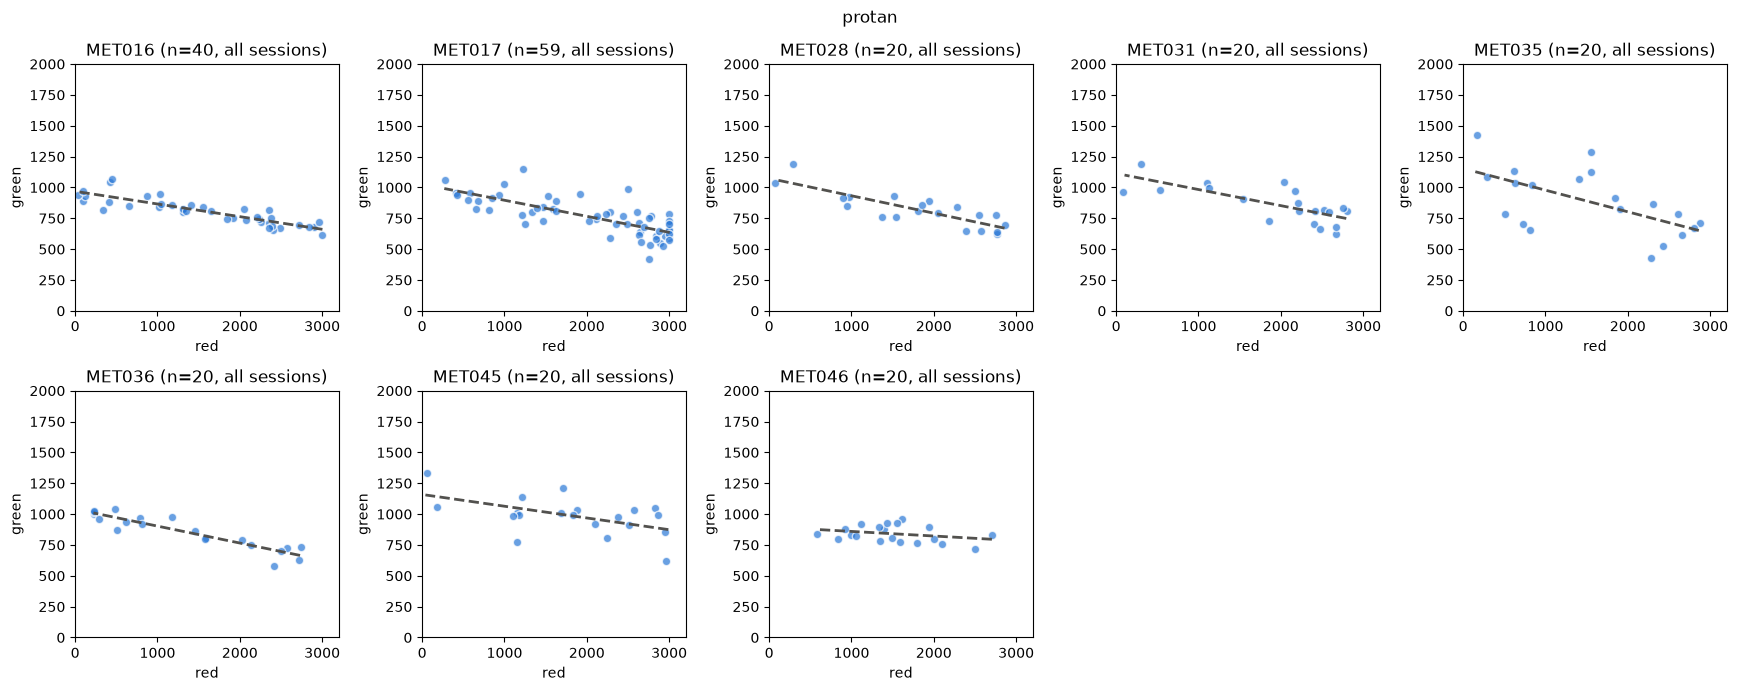

In [2]:
plotting.plot_subjects_grid(df, subgroup='protan', show_fit=True);

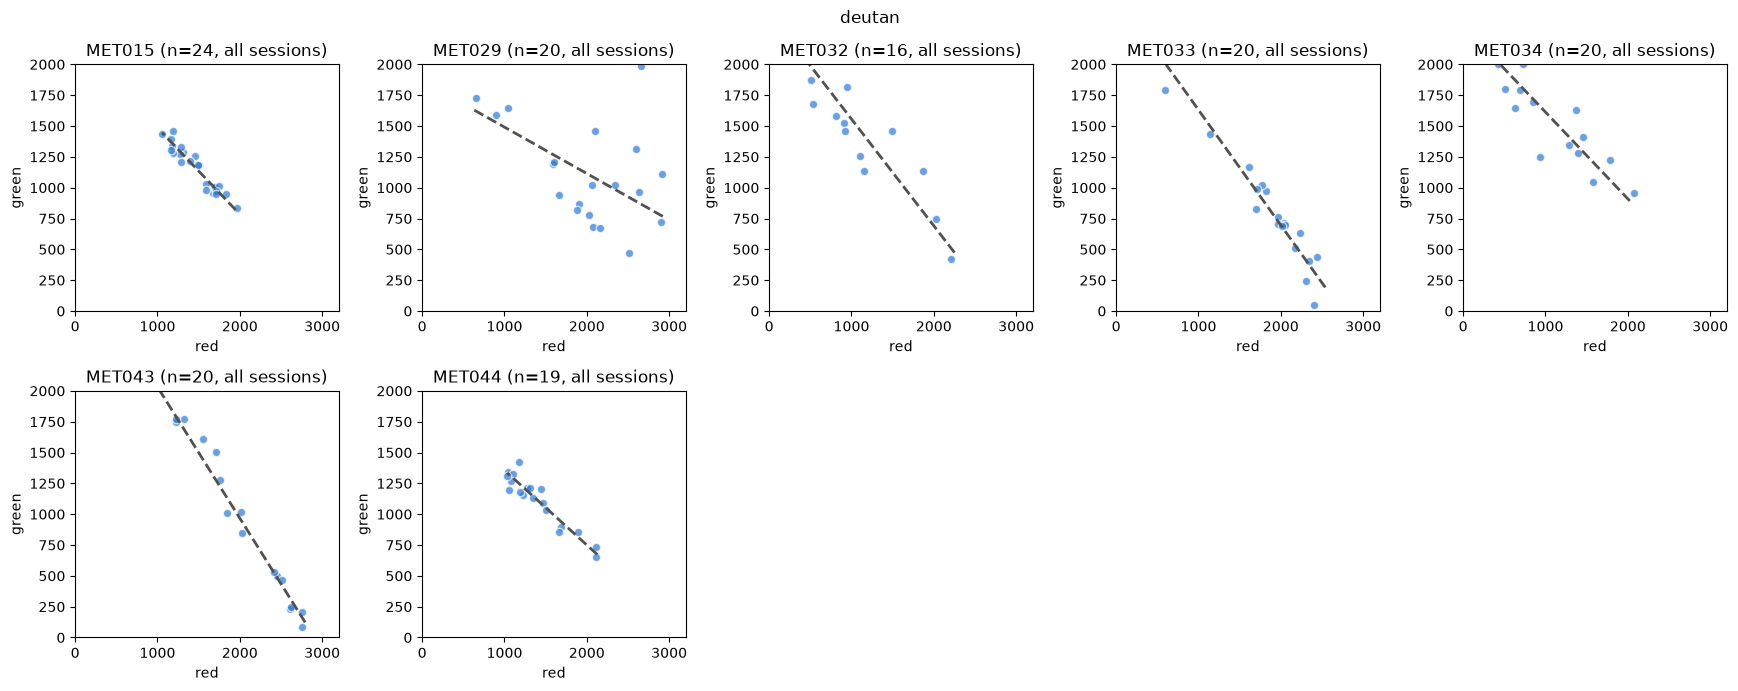

In [3]:
plotting.plot_subjects_grid(df, subgroup='deutan', show_fit=True);

## Feature space: does shape separate protan from deutan?

One point per subject, in shape-feature space -- capped at 3 categories per
plot (the dataviz skill's all-pairs scatter color limit), so protan/deutan
first, then HC alongside for context.

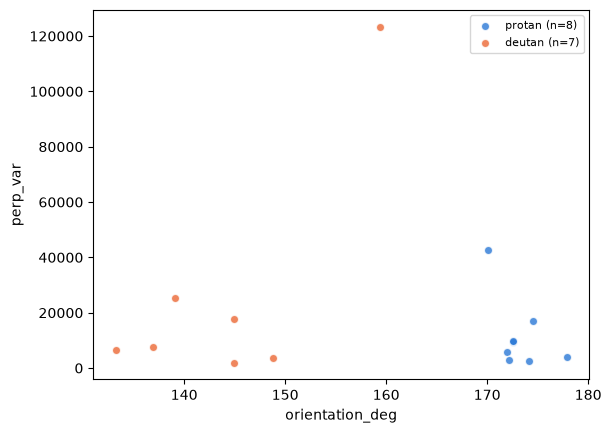

In [4]:
pd_categories = [
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]
plotting.plot_feature_space(df, pd_categories, x_feature='orientation_deg', y_feature='perp_var');

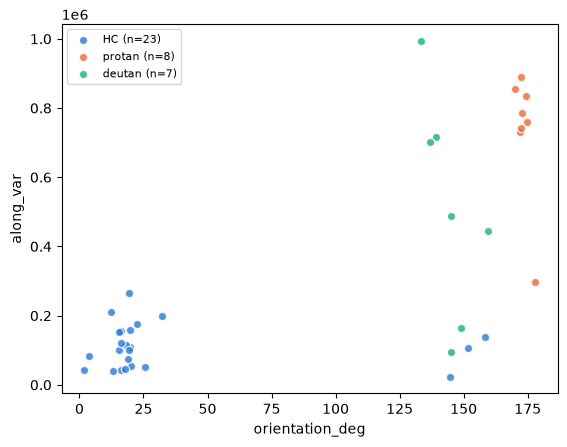

In [5]:
hc_pd_categories = [
    {'label': 'HC', 'group': 'CTR'},
    {'label': 'protan', 'subgroup': 'protan'},
    {'label': 'deutan', 'subgroup': 'deutan'},
]
plotting.plot_feature_space(df, hc_pd_categories, x_feature='orientation_deg', y_feature='along_var');

## The five group comparisons (same pairs as M1), per shape feature

Mann-Whitney U + effect size (`features.compare_shape_feature`), not a
single omnibus statistic -- run once per feature so a difference can be
attributed to a specific shape property (orientation, along-line spread, or
off-line scatter) rather than just "the groups differ somehow".

In [6]:
comparison_specs = [
    ('HC vs PD', dict(group1='CTR', group2='PD')),
    ('HC vs CVD', dict(group1='CTR', group2='CVD')),
    ('HC vs protan', dict(group1='CTR', group2='CVD', subgroup2='protan')),
    ('HC vs deutan', dict(group1='CTR', group2='CVD', subgroup2='deutan')),
    ('protan vs deutan', dict(group1='CVD', subgroup1='protan', group2='CVD', subgroup2='deutan')),
]

rows = []
for feature in ['orientation_deg', 'along_var', 'perp_var']:
    for label, kw in comparison_specs:
        r = features.compare_shape_feature(df, feature, **kw)
        rows.append({'feature': feature, 'comparison': label, 'n1': r['n1'], 'n2': r['n2'], 'p_value': r['p_value'], 'rbc': r['rbc'], 'cles': r['cles']})
shape_results = pd.DataFrame(rows)
shape_results.pivot(index='comparison', columns='feature', values='p_value').loc[[c for c, _ in comparison_specs]]

feature,along_var,orientation_deg,perp_var
comparison,,,
HC vs PD,3.381586e-02,6.325484e-03,0.029912
HC vs CVD,4.243925e-06,2.750044e-06,0.811173
HC vs protan,2.535264e-07,2.535264e-07,0.579728
HC vs deutan,1.156302e-03,5.540819e-04,0.848038
protan vs deutan,7.210567e-02,3.108003e-04,0.694328


`orientation_deg` separates **protan vs. deutan perfectly** (p=0.0003,
rbc=1.0, cles=1.0 -- every protan subject's line orientation falls on one
side of every deutan subject's, U at its maximum possible value for n=8,7).
That is a cleaner split than M1's mean-location Hotelling T² (p=0.004) got
on the same two groups, and far cleaner than SSVEP's `ramp_slope_red`
(p=0.44) -- the line's *direction* carries more subtyping signal than its
*position*. `along_var` trends the same way (p=0.07) but doesn't clear
significance at this n. `perp_var` (match consistency/noise) does not
separate any group pair here -- HC vs PD is the only borderline case
(p=0.03 on both `along_var` and `perp_var`), everything else involving CVD
is p>0.5. Every group difference in this dataset, mean or shape, is carried
by *where the isoluminance line sits and points* -- not by how noisily a
subject clicks.